Ridership ≈ Service × Demand × Accessibility

In [1]:
# import sys
# !{sys.executable} -m ensurepip --upgrade

In [2]:
import sys
!{sys.executable} -m pip install linearmodels


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [3]:
# Importing necessary package 
import pandas as pd 
import geopandas as gpd
pd.set_option('display.max_columns', None)
import os
import google.auth
import gcsfs
fs = gcsfs.GCSFileSystem()
import statsmodels.api as sm
import numpy as np
from scipy.stats import skew


import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
GCS_FILE_PATH = 'gs://calitp-analytics-data/data-analyses/ahsc_grant/ahsc_riderships/AHSC_2026'

In [5]:
with fs.open(f"{GCS_FILE_PATH}/stop_route_df.parquet", "rb") as f: 
    stop_route_df = gpd.read_parquet(f)

with fs.open(f"{GCS_FILE_PATH}/stop_route_df_saturday.parquet", "rb") as f: 
    stop_route_df_saturday = gpd.read_parquet(f)

with fs.open(f"{GCS_FILE_PATH}/stop_route_df_sunday.parquet", "rb") as f: 
    stop_route_df_sunday = gpd.read_parquet(f)

In [6]:
stop_route_df.head(2)

,organization_name,feed_key,stop_id,stop_name,stop_code,n_arrivals,n_routes,pt_geom,day_type,route_id_list,average_daily_boardings,average_daily_alightings,start_date,end_date,geometry,total_pop_adj,poverty_pop_adj,non_us_citizen_adj,workers_with_no_car_adj,households_with_no_cars_adj,disabled_pop_adj,public_asst_pop_adj,inc_extremelylow_adj,inc_verylow_adj,inc_low_adj,male_seniors_adj,female_seniors_adj,veteran_pop_adj,male_youth_adj,inc_total_lowincome_adj,female_youth_adj,total_seniors_adj,jobs_tot_adj,total_youth_adj,ALAND_adj,poi_total_adj
0,Gold Coast Transit,3cb676436aad669e52042c0e97a9a051,VNACLR1,.,None,14.0,1.0,POINT(-119.294028 34.343645),Weekday,['16'],0.00000,3.000000,2025-05-01,2025-05-31,POINT (64936.582 -407800.219),10.425292,0.979690,0.739468,0.100038,0.112829,1.441372,0.545430,2.306134,2.548643,0.894414,0.992410,1.270627,0.480009,0.476575,5.749192,0.656547,2.263038,6.588764,1.133122,496201.411578,0.031563
1,Samtrans,db97cc02836aa5f0cf647d80160b23ec,345017,1000 El Camino Real-Menlo College,345017,72.0,1.0,POINT(-122.191284 37.457543),Weekday,['ECR-216'],9.52381,24.571429,2025-08-01,2025-08-31,POINT (-193547.746 -59885.338),624.726883,34.432788,109.726839,59.474563,31.053582,44.774152,11.461357,81.434546,97.336393,39.904405,45.567698,71.082024,19.466454,34.613280,218.675344,92.571414,116.649722,331.502428,127.184694,513409.572630,8.328826


In [7]:
# Convert n_arrivals and n_routes to integer
stop_route_df['n_arrivals'] = stop_route_df['n_arrivals'].fillna(0).astype(int)
stop_route_df['n_routes'] = stop_route_df['n_routes'].fillna(0).astype(int)
stop_route_df_saturday['n_arrivals'] = stop_route_df_saturday['n_arrivals'].fillna(0).astype(int)
stop_route_df_saturday['n_routes'] = stop_route_df_saturday['n_routes'].fillna(0).astype(int)
stop_route_df_sunday['n_arrivals'] = stop_route_df_sunday['n_arrivals'].fillna(0).astype(int)
stop_route_df_sunday['n_routes'] = stop_route_df_sunday['n_routes'].fillna(0).astype(int)

In [8]:
stop_route_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 21315 entries, 0 to 21314
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   organization_name            21315 non-null  object  
 1   feed_key                     21315 non-null  object  
 2   stop_id                      21315 non-null  object  
 3   stop_name                    21315 non-null  object  
 4   stop_code                    20594 non-null  object  
 5   n_arrivals                   21315 non-null  int64   
 6   n_routes                     21315 non-null  int64   
 7   pt_geom                      21315 non-null  object  
 8   day_type                     21315 non-null  object  
 9   route_id_list                21315 non-null  object  
 10  average_daily_boardings      21315 non-null  float64 
 11  average_daily_alightings     19138 non-null  float64 
 12  start_date                   21315 non-null  object 

In [9]:
# Min-max normalize selected columns to a 0–1 scale
# Each value is rescaled relative to the column minimum and maximum:
# (x - min) / (max - min)
# Resulting "_norm" columns allow comparison across variables with different units/scales
cols = ["total_pop_adj", "jobs_tot_adj", "poi_total_adj"]

for c in cols:
    stop_route_df[c + "_norm"] = (
        (stop_route_df[c] - stop_route_df[c].min()) /
        (stop_route_df[c].max() - stop_route_df[c].min())
    )

In [10]:
stop_route_df["land_use_index"] = (
    stop_route_df["total_pop_adj_norm"] +
    stop_route_df["jobs_tot_adj_norm"] +
    stop_route_df["poi_total_adj_norm"]
) / 3

In [11]:
stop_route_df.head(5)

,organization_name,feed_key,stop_id,stop_name,stop_code,n_arrivals,n_routes,pt_geom,day_type,route_id_list,average_daily_boardings,average_daily_alightings,start_date,end_date,geometry,total_pop_adj,poverty_pop_adj,non_us_citizen_adj,workers_with_no_car_adj,households_with_no_cars_adj,disabled_pop_adj,public_asst_pop_adj,inc_extremelylow_adj,inc_verylow_adj,inc_low_adj,male_seniors_adj,female_seniors_adj,veteran_pop_adj,male_youth_adj,inc_total_lowincome_adj,female_youth_adj,total_seniors_adj,jobs_tot_adj,total_youth_adj,ALAND_adj,poi_total_adj,total_pop_adj_norm,jobs_tot_adj_norm,poi_total_adj_norm,land_use_index
0,Gold Coast Transit,3cb676436aad669e52042c0e97a9a051,VNACLR1,.,None,14,1,POINT(-119.294028 34.343645),Weekday,['16'],0.000000,3.000000,2025-05-01,2025-05-31,POINT (64936.582 -407800.219),10.425292,0.979690,0.739468,0.100038,0.112829,1.441372,0.545430,2.306134,2.548643,0.894414,0.992410,1.270627,0.480009,0.476575,5.749192,0.656547,2.263038,6.588764,1.133122,496201.411578,0.031563,0.000796,0.000773,0.000031,0.000533
1,Samtrans,db97cc02836aa5f0cf647d80160b23ec,345017,1000 El Camino Real-Menlo College,345017,72,1,POINT(-122.191284 37.457543),Weekday,['ECR-216'],9.523810,24.571429,2025-08-01,2025-08-31,POINT (-193547.746 -59885.338),624.726883,34.432788,109.726839,59.474563,31.053582,44.774152,11.461357,81.434546,97.336393,39.904405,45.567698,71.082024,19.466454,34.613280,218.675344,92.571414,116.649722,331.502428,127.184694,513409.572630,8.328826,0.047722,0.050806,0.014316,0.037615
2,Samtrans,db97cc02836aa5f0cf647d80160b23ec,343119,1011 Crestview Dr,343119,5,1,POINT(-122.284103 37.484282),Weekday,['61-216'],1.444444,1.888889,2025-08-01,2025-08-31,POINT (-201672.936 -56720.285),618.671353,16.934691,52.913442,4.731674,4.629433,50.343946,1.138993,71.601348,49.274438,41.048349,70.098162,69.817799,13.378741,21.213500,161.924135,40.041064,139.915961,334.477659,61.254564,516743.528919,0.739624,0.047259,0.051264,0.001250,0.033258
3,Samtrans,db97cc02836aa5f0cf647d80160b23ec,340606,1060 Carolan Ave,340606,7,1,POINT(-122.359627 37.586685),Weekday,['46-216'],10.333333,5.500000,2025-08-01,2025-08-31,POINT (-208056.618 -45176.880),1438.793530,132.449436,221.389693,11.302511,16.811715,91.359525,23.425545,220.791180,130.391191,92.157087,90.232509,119.205647,15.839970,78.184456,443.339458,87.599288,209.438156,645.868640,165.783743,491044.010802,9.815698,0.109907,0.099216,0.016876,0.075333
4,SDMTS,1fff52f9349da228c56eef492df5001b,12049,10th Av & A St,12049,18,3,POINT(-117.15569071 32.71857729),Weekday,"['110', '280', '290']",3.485637,42.889568,2024-09-01,2025-01-25,POINT (266991.751 -584189.054),5237.572429,1435.161120,593.226153,612.453346,996.367561,960.903569,687.220269,1386.671494,898.469086,891.580091,352.299644,231.802090,364.548984,187.722238,3176.720671,380.320369,584.101734,1948.084219,568.042607,515427.813601,119.358253,0.400088,0.299744,0.205473,0.301768


### Log-linear Regression Model

In [12]:
stop_route_df_selected_org = stop_route_df[
    stop_route_df['organization_name'].isin([
        'SamTrans',
        'Golden Gate Transit',
        'Long Beach Transit',
        'SDMTS',
        # 'Golden Gate Park Shuttle',
        # 'Fresno County',
        'San Francisco Bay Area Rapid Transit District',
        'Big Blue Bus',
        'Caltrain',
        # 'Culver City Bus',
        # 'Foothill Transit',
        'Riverside Transit',
        'Gold Coast Transit',
        'SacRT Bus',
        'Orange County Transportation Authority'
    ])
]

In [13]:
# Log-linear regression
# Dependent variable: log('average_daily_boardings')
# Predictors: n_trips, n_routes, total_pop_adj, households_with_no_cars_adj, jobs_tot_adj

# Copy the dataframe
df = stop_route_df_selected_org.copy()

# 2. Create log dependent variable
# Replace 0 with NaN BEFORE log (log(0) = -inf)
df['log_boardings'] = np.log(df['average_daily_boardings'].replace(0, np.nan))
df['log_arrivals'] = np.log(df['n_arrivals'].replace(0, np.nan))

# 3. Select only rows with all needed variables
df = df.dropna(subset=[
    'average_daily_boardings',
    'log_arrivals',
    'land_use_index',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'inc_total_lowincome_adj',
    'disabled_pop_adj'
    
])

# 4. Define Y and X
y = df['average_daily_boardings']

X = df[['log_arrivals',
        'land_use_index', 'workers_with_no_car_adj', 'total_youth_adj', 'inc_total_lowincome_adj', 'disabled_pop_adj']]

# 5. Add constant
X = sm.add_constant(X)

# 6. Fit model
model = sm.OLS(y, X).fit()

# 7. Show results
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     average_daily_boardings   R-squared:                       0.090
Model:                                 OLS   Adj. R-squared:                  0.090
Method:                      Least Squares   F-statistic:                     261.8
Date:                     Mon, 22 Jun 2026   Prob (F-statistic):          1.42e-320
Time:                             20:45:42   Log-Likelihood:            -1.2249e+05
No. Observations:                    15820   AIC:                         2.450e+05
Df Residuals:                        15813   BIC:                         2.451e+05
Df Model:                                6                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

- About 5.6% of the variation in dependent variable (here, stop-level ridership) is explained by the predictors in the model.
- 94.4% of the variation is due to other factors not captured by this model.
- Skew = 54.357 → Residuals are extremely asymmetric, violating normality.
- Kurtosis = 4235.968 → Residuals have ultra‑heavy tails, far from a normal distribution.
- JB statistic = 15 billion → The Jarque–Bera test overwhelmingly rejects normality.
- Durbin–Watson = 1.374 → Strong positive autocorrelation remains in the residuals.
- Condition number = 1.92e+04 → Predictors have scaling issues and possible multicollinearity.

### Checking Multicollinearity using VIF

VIF checks multicollinearity (correlation among predictors)

- Idea:
If a variable can be well explained by other predictors,
its coefficient becomes unstable and its standard error increases
- Interpretation:
VIF ≈ 1   → no correlation (good);
VIF > 5   → moderate concern;
VIF > 10  → serious multicollinearity
- Key point:
High VIF doesn't bias coefficients, but makes them noisy and hard to interpret

In [14]:
# Selecting only numeric regressors (Ridership ≈ Service × Demand × Accessibility)
X = stop_route_df_selected_org[
    ['disabled_pop_adj', 'inc_total_lowincome_adj',  'total_youth_adj', 'workers_with_no_car_adj']
].copy()

# Add constant
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_df)

                  variable       VIF
0                    const  3.233608
1         disabled_pop_adj  6.488191
2  inc_total_lowincome_adj  8.545345
3          total_youth_adj  2.301681
4  workers_with_no_car_adj  1.931072


All predictors have low VIFs (≈1–1.8), which means very little multicollinearity among chosen variables.
The model’s coefficients should therefore be stable and interpretable, with no inflation of standard errors.
The high VIF on the constant is not meaningful and can be ignored.

In [15]:
stop_route_df['average_daily_boardings'].describe()

count    21315.000000
mean        50.886533
std        504.743434
min          0.000000
25%          1.627594
50%          6.300000
75%         21.378255
max      41893.868537
Name: average_daily_boardings, dtype: float64

Data is highly skewed (28.63) .
Skewed data is data that isn’t evenly distributed around the center, values bunch up on one side and stretch into a long tail.
This means a few stops have very high boardings and push the distribution out into a long tail.
75% of stops board ≤ 20 people

Possible solution: Use a count model (Poisson or Negative Binomial)  
Other models to check:
- Poisson
- Negative Binomial (handles overdispersion better)
- Zero‑inflated Poisson (if many zeros)
- Zero‑inflated NB (most flexible)

### Add organization fixed effects

In [16]:
df = stop_route_df_selected_org.copy()

# Log transforms (safe)
df['log_boardings'] = np.log(df['average_daily_boardings'].replace(0, np.nan))
df['log_arrivals'] = np.log(df['n_arrivals'].replace(0, np.nan))

# Keep needed columns
df = df.dropna(subset=[
    'log_boardings',
    'log_arrivals',
    'land_use_index',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'inc_total_lowincome_adj',
    'disabled_pop_adj',
    'organization_name'
])

# Dependent variable
y = df['log_boardings']

# Predictors
X = df[
    ['log_arrivals',
     'land_use_index',
     'workers_with_no_car_adj',
     'total_youth_adj',
     'inc_total_lowincome_adj',
     'disabled_pop_adj']
]

# Force numeric
y = pd.to_numeric(y)
X = X.apply(pd.to_numeric, errors='coerce')

# Organization fixed effects
org_fe = pd.get_dummies(df['organization_name'], drop_first=True).astype(float)

# Combine
X = pd.concat([X, org_fe], axis=1)

# Drop ANY remaining bad rows together (IMPORTANT STEP)
df_model = pd.concat([y, X], axis=1).dropna()

y = df_model['log_boardings']
X = df_model.drop(columns=['log_boardings'])

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_boardings   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                     910.9
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:45:42   Log-Likelihood:                -23412.
No. Observations:               14198   AIC:                         4.685e+04
Df Residuals:                   14183   BIC:                         4.697e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

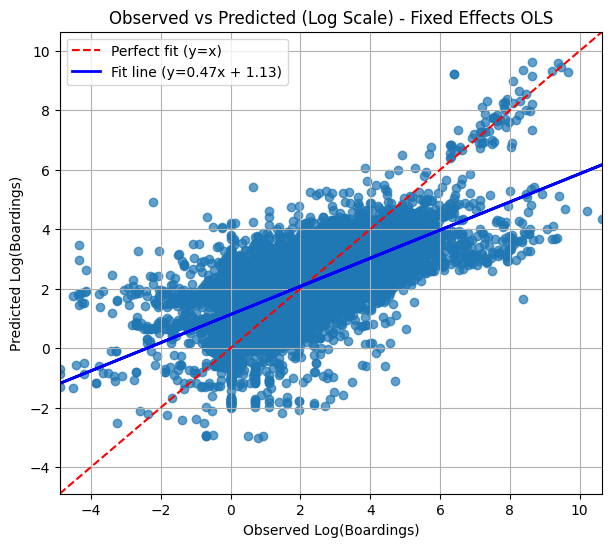

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Predicted and observed (log space)
log_pred = model.predict(X)
log_observed = df['log_boardings']

plt.figure(figsize=(7, 6))

plt.scatter(log_observed, log_pred, alpha=0.7)

# perfect fit line (y = x)
lims = [
    min(log_observed.min(), log_pred.min()),
    max(log_observed.max(), log_pred.max())
]

plt.plot(lims, lims, color="red", linestyle="--", label="Perfect fit (y=x)")

# fit line y = mx + c
m, c = np.polyfit(log_observed, log_pred, 1)
plt.plot(log_observed, m * log_observed + c,
         color="blue", linewidth=2,
         label=f"Fit line (y={m:.2f}x + {c:.2f})")

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Observed Log(Boardings)")
plt.ylabel("Predicted Log(Boardings)")
plt.title("Observed vs Predicted (Log Scale) - Fixed Effects OLS")
plt.grid(True)
plt.legend()

plt.show()

In [27]:
from linearmodels.iv import IV2SLS

df = stop_route_df_selected_org.copy()

# Log transforms
df['log_boardings'] = np.log(df['average_daily_boardings'].replace(0, np.nan))
df['log_arrivals']  = np.log(df['n_arrivals'].replace(0, np.nan))

# Demographic rates (area ratio cancels in division)
df['pct_youth']     = df['total_youth_adj'] / df['total_pop_adj']
df['pct_lowincome'] = df['inc_total_lowincome_adj'] / df['total_pop_adj']
df['pct_disabled']  = df['disabled_pop_adj'] / df['total_pop_adj']

df = df.dropna(subset=[
    'log_boardings', 'log_arrivals', 'land_use_index',
    'pct_youth', 'pct_lowincome', 'pct_disabled',
    'organization_name', 'n_routes'
])

# Org fixed effects
org_fe = pd.get_dummies(df['organization_name'], drop_first=True).astype(float)

# Exogenous regressors (pct_no_car dropped - collinear with land_use_index)
exog = pd.concat([
    df[['land_use_index', 'pct_youth', 'pct_lowincome', 'pct_disabled']],
    org_fe
], axis=1)
exog = sm.add_constant(exog)

# Final IV-2SLS model
iv_final = IV2SLS(
    dependent=df['log_boardings'],
    exog=exog,
    endog=df[['log_arrivals']],   # endogenous: agencies add service where ridership is high
    instruments=df[['n_routes']]  # instrument: network supply decision, not demand-driven
).fit(cov_type='robust')

print(iv_final.summary)

# Diagnostics
print(iv_final.first_stage.summary)  # F > 10 confirms strong instrument
print(iv_final.wu_hausman())          # confirms IV was necessary over OLS

                          IV-2SLS Estimation Summary                          
Dep. Variable:          log_boardings   R-squared:                      0.4796
Estimator:                    IV-2SLS   Adj. R-squared:                 0.4791
No. Observations:               14187   F-statistic:                 1.428e+04
Date:                Mon, Jun 22 2026   P-value (F-stat)                0.0000
Time:                        21:44:49   Distribution:                 chi2(13)
Cov. Estimator:                robust                                         
                                                                              
                                               Parameter Estimates                                               
                                               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------------------------
const                     

The Wu–Hausman test rejects the null hypothesis that the endogenous regressor is exogenous (F(1, 14172) = 12.65, p = 0.0004). This provides evidence of endogeneity, indicating that OLS estimates are inconsistent and supporting the use of the instrumental variables estimator.

In this model, the key methodological challenge is that log_arrivals (the number of scheduled transit arrivals at a stop) is endogenous, transit agencies don't randomly assign service, they add more buses and trains to stops that already have high ridership, meaning log_arrivals and the error term are correlated, which would bias OLS estimates. To correct for this, we use n_routes (the number of routes serving a stop) as an instrumental variable: it's a valid instrument because it strongly predicts how many arrivals a stop gets (more routes mechanically means more scheduled arrivals, strong first stage), but the number of routes serving a stop is a network-level planning decision that doesn't directly cause riders to board independently of the arrivals it generates (exclusion restriction). With log_arrivals instrumented by n_routes, the model then estimates the effect of service frequency on boardings alongside exogenous demand-side predictors — land use mix, share of low-income residents, share of youth, and share of disabled residents,  while controlling for agency-level fixed effects to absorb baseline differences in how each transit operator's stops perform.

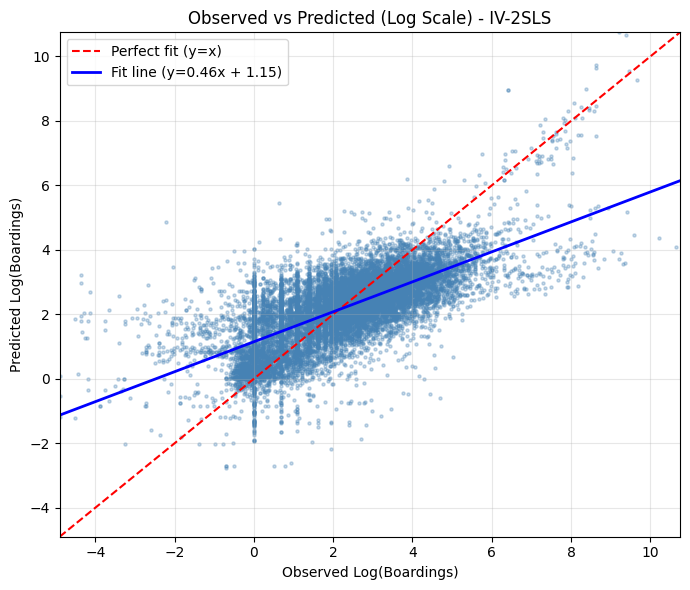

In [30]:
# Get fitted values and observed
log_pred     = iv_final.fitted_values.squeeze()
log_observed = df['log_boardings'].values

plt.figure(figsize=(7, 6))
plt.scatter(log_observed, log_pred, alpha=0.3, s=5, color='steelblue')

# Perfect fit line (y = x)
lims = [
    min(log_observed.min(), log_pred.min()),
    max(log_observed.max(), log_pred.max())
]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect fit (y=x)")

# Fit line y = mx + c
m, c = np.polyfit(log_observed, log_pred, 1)
plt.plot(np.array(lims), m * np.array(lims) + c,
         color="blue", linewidth=2,
         label=f"Fit line (y={m:.2f}x + {c:.2f})")

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Observed Log(Boardings)")
plt.ylabel("Predicted Log(Boardings)")
plt.title("Observed vs Predicted (Log Scale) - IV-2SLS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('iv_obs_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

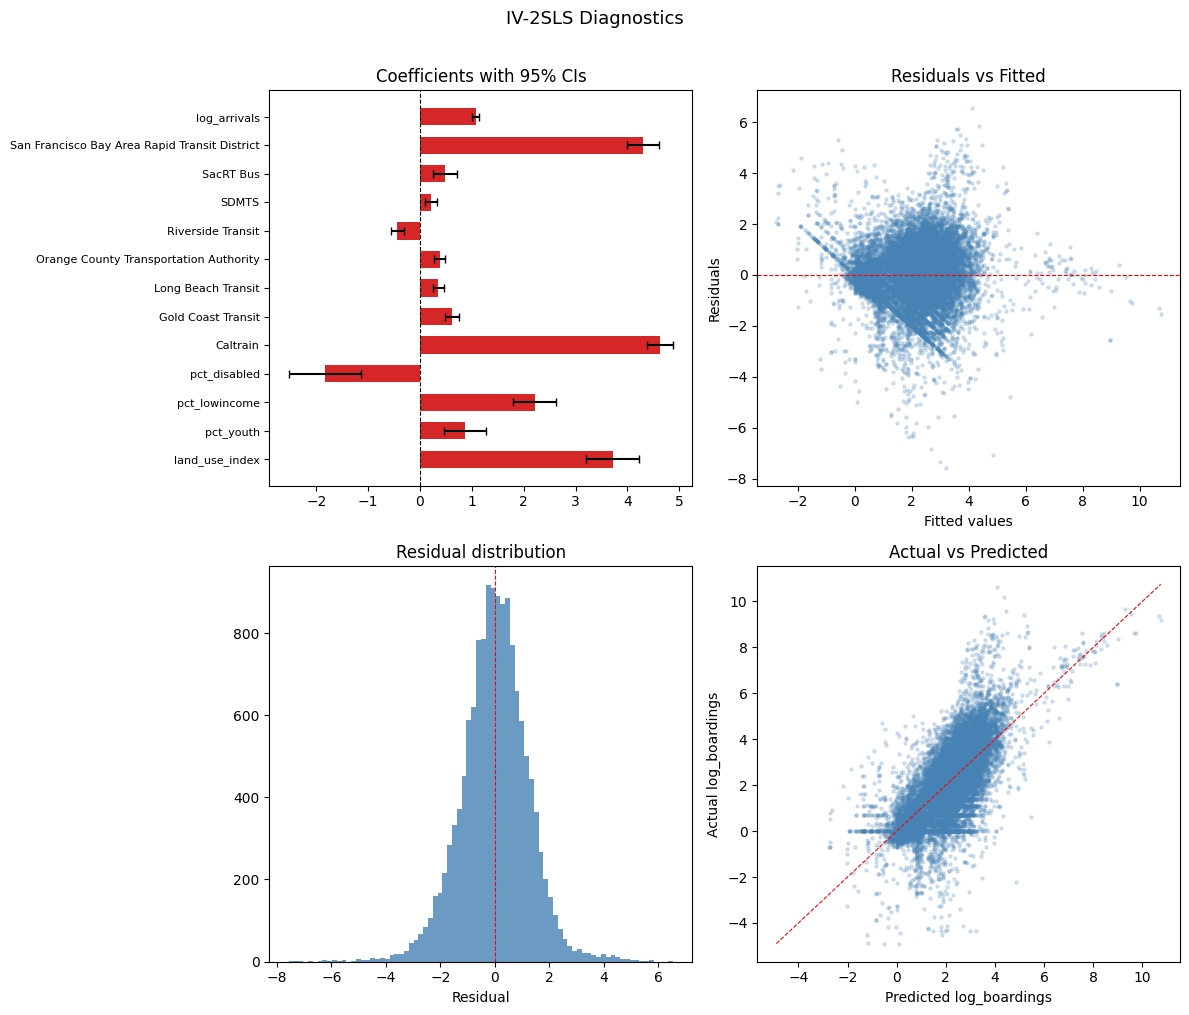

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

params = iv_final.params.drop('const')
ci     = iv_final.conf_int().drop('const')
fitted = iv_final.fitted_values.squeeze()
resid  = iv_final.resids.squeeze()
actual = df['log_boardings'].values

# 1. Coefficient plot
colors = ['#d62728' if ci.loc[v, 'lower'] > 0 or ci.loc[v, 'upper'] < 0
          else '#aec7e8' for v in params.index]
axes[0,0].barh(range(len(params)), params.values,
               xerr=[params.values - ci['lower'].values, ci['upper'].values - params.values],
               color=colors, capsize=3, height=0.6)
axes[0,0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,0].set_yticks(range(len(params)))
axes[0,0].set_yticklabels(params.index, fontsize=8)
axes[0,0].set_title('Coefficients with 95% CIs')

# 2. Residuals vs fitted
axes[0,1].scatter(fitted, resid, alpha=0.2, s=5, color='steelblue')
axes[0,1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[0,1].set_xlabel('Fitted values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals vs Fitted')

# 3. Residual distribution
axes[1,0].hist(resid, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1,0].axvline(0, color='red', linewidth=0.8, linestyle='--')
axes[1,0].set_xlabel('Residual')
axes[1,0].set_title('Residual distribution')

# 4. Actual vs predicted
axes[1,1].scatter(fitted, actual, alpha=0.2, s=5, color='steelblue')
mn, mx = min(fitted.min(), actual.min()), max(fitted.max(), actual.max())
axes[1,1].plot([mn, mx], [mn, mx], color='red', linewidth=0.8, linestyle='--')
axes[1,1].set_xlabel('Predicted log_boardings')
axes[1,1].set_ylabel('Actual log_boardings')
axes[1,1].set_title('Actual vs Predicted')

plt.suptitle('IV-2SLS Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('iv_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

- Coefficients with 95% CIs (top left).
- Residuals vs Fitted (top right): funnel shape — variance is small at low fitted values and explodes at high fitted values. This is heteroskedasticity, meaning standard errors are not constant.
- Residual Distribution (bottom left)
Roughly bell-shaped and centered on zero — good. It's slightly leptokurtic (taller and narrower than normal), meaning more extreme residuals than a normal distribution would predict.


### Poisson Model

In [13]:
# Copy the dataset
df = stop_route_df_selected_org.copy()

# 2. Select needed variables (drop missing)
df = df.dropna(subset=[
    'average_daily_boardings',
    'n_arrivals', 'n_routes',
    'total_pop_adj', 'workers_with_no_car_adj', 'poverty_pop_adj'
])

# 3. Define Y and X
y = df['average_daily_boardings']

X = df[['n_arrivals', 'n_routes',
        'land_use_index', 'workers_with_no_car_adj', 'total_youth_adj', 'inc_total_lowincome_adj', 'disabled_pop_adj' ]]

# 4. Add intercept
X = sm.add_constant(X)

# 5. Fit Poisson GLM
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# 6. Output summary
print(poisson_model.summary())


                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                19474
Model:                                 GLM   Df Residuals:                    19466
Model Family:                      Poisson   Df Model:                            7
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:            -1.8468e+06
Date:                     Thu, 21 May 2026   Deviance:                   3.6216e+06
Time:                             17:17:58   Pearson chi2:                 2.36e+07
No. Iterations:                         15   Pseudo R-squ. (CS):              1.000
Covariance Type:                 nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

This Poisson model fits very poorly: the Pearson chi‑square is huge, meaning the data are heavily over‑dispersed and the Poisson assumptions break.
- The coefficient for n_arrivals (0.0253) means each extra trip increases expected ridership by about 2.5%.
- n_routes (-1.3051) is negative, which is unrealistic and indicates model misspecification due to over‑dispersion.
- total_pop_adj is negative, also unrealistic — another sign the Poisson model is not appropriate.
- workers_with_no_car_adj is positive, meaning more zero‑car households predict higher ridership.
- poverty_pop_adj is positive, meaning as the adjusted population living below the poverty level increases in a transit agency’s service area, ridership tends to increase.
Overall: the Poisson model’s signs are distorted.

Pearson chi‑square = 3.09e+07 and Degrees of freedom ≈ 21264.
Hence, 
Dispersion estimate = Pearson χ² / df; 3.09e+07 / 21264 ≈ 1453.5

A valid Poisson model should have dispersion ≈ 1. Dispersion ≈ 1453.5, which means:
Poisson model is severely overdispersed. >1 → overdispersion (variance is larger than the model assumes).

Variance >> mean:
- Poisson standard errors become too small
- p‑values become artificially tiny
- coefficients look falsely “precise”
- model fit is misleading"

### Negative Binomial Model

In [14]:
stop_route_df.organization_name.unique()

array(['Gold Coast Transit', 'Samtrans', 'SDMTS', 'Fresno County',
       'SacRT Bus', 'San Francisco Bay Area Rapid Transit District',
       'Orange County Transportation Authority', 'Long Beach Transit',
       'Foothill Transit', 'Golden Gate Park Shuttle', 'Big Blue Bus',
       'Culver City Bus', 'Riverside Transit', 'Caltrain',
       'City of Burbank'], dtype=object)

In [15]:
stop_route_df_selected_org.columns

Index(['organization_name', 'feed_key', 'stop_id', 'stop_name', 'stop_code',
       'n_arrivals', 'n_routes', 'pt_geom', 'day_type', 'route_id_list',
       'average_daily_boardings', 'average_daily_alightings', 'start_date',
       'end_date', 'geometry', 'total_pop_adj', 'poverty_pop_adj',
       'non_us_citizen_adj', 'workers_with_no_car_adj',
       'households_with_no_cars_adj', 'disabled_pop_adj',
       'public_asst_pop_adj', 'inc_extremelylow_adj', 'inc_verylow_adj',
       'inc_low_adj', 'male_seniors_adj', 'female_seniors_adj',
       'veteran_pop_adj', 'male_youth_adj', 'inc_total_lowincome_adj',
       'female_youth_adj', 'total_seniors_adj', 'jobs_tot_adj',
       'total_youth_adj', 'ALAND_adj', 'poi_total_adj', 'total_pop_adj_norm',
       'jobs_tot_adj_norm', 'poi_total_adj_norm', 'land_use_index'],
      dtype='object')

In [18]:
stop_route_df_selected_org["land_use_index"].describe()

count    19474.000000
mean         0.086627
std          0.057366
min          0.000110
25%          0.049817
50%          0.077014
75%          0.107845
max          0.767402
Name: land_use_index, dtype: float64

In [20]:
vif = pd.DataFrame()
vif["var"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)

,var,VIF
0,const,136.425077
6,log_inc_total_lowincome_adj,21.318487
7,log_disabled_pop_adj,9.456262
5,log_total_youth_adj,6.813041
3,land_use_index,3.161617
4,log_workers_with_no_car_adj,2.343980
2,log_arrivals,1.301694
1,n_routes,1.212077


In [28]:
df["log_arrivals"].describe()

count    19474.000000
mean         3.452859
std          0.885842
min          0.000000
25%          3.044522
50%          3.496508
75%          4.077537
max          6.568078
Name: log_arrivals, dtype: float64

In [20]:
# Copy the dataset
df = stop_route_df_selected_org.copy()
y = df['average_daily_boardings']

X = df[['n_arrivals', 'n_routes',
        'land_use_index', 'workers_with_no_car_adj', 'poverty_pop_adj', 'disabled_pop_adj']]

# 4. Add intercept
X = sm.add_constant(X)

# Same X and y as  Poisson
nb_model_extended_final = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_extended_final.summary())

/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                15820
Model:                                 GLM   Df Residuals:                    15813
Model Family:             NegativeBinomial   Df Model:                            6
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -63521.
Date:                     Mon, 22 Jun 2026   Deviance:                       33534.
Time:                             21:17:17   Pearson chi2:                 5.81e+05
No. Iterations:                         80   Pseudo R-squ. (CS):             0.8943
Covariance Type:                 nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

If we keep both demand variables (like population and income) and supply variables (like arrivals and routes) in the same model, then the estimated coefficients should be interpreted as conditional effects rather than direct causal relationships. In this setup, population does not represent total potential demand in isolation, but rather the remaining variation in ridership after accounting for where and how much transit service is provided. Because transit agencies tend to allocate more frequent service and more routes to high-population areas, population and service intensity become strongly intertwined in the data. As a result, once service levels are controlled for, the model attributes much of the shared variation to supply variables, and the residual association for population can shrink, flip sign, or reflect only differences in ridership efficiency across similarly served areas. This means the population coefficient is not measuring “more people leads to less ridership,” but rather “among places with similar service levels, higher population does not necessarily correspond to additional ridership beyond what service already explains.”

### Negative Binomial Model 

The Negative Binomial model behaves much better than the Poisson model because it corrects the strongly overdispersed nature of ridership data. After switching to a Negative Binomial model, the dispersion dropped to a reasonable level (≈5), the standard errors became realistic, the z‑values returned to interpretable ranges, and the overall fit stabilized. 


The NB model is used when:
- counts vary wildly
- some stops have way more riders than others
- data is highly skewed
- there are outliers or “hot spots”

Variance > Mean
This matches real transit ridership perfectly.

In the above model,
Pseudo R² (Cragg‑Uhler / Nagelkerke): 0.8978
Very high — the predictors explain a large proportion of the variation in ridership.
For transit ridership data (often noisy and over‑dispersed), this is exceptionally strong.



### Variables Interpretation

1. n_arrivals coefficient = 0.0425
Interpretation: Each additional trip serving the stop increases expected daily boardings by:
exp(0.0425) − 1 ≈ 4.34%

2. n_routes coefficient = 0.1426
Interpretation: For stops/agencies where n_routes_effective > 0 (aggregated stop-level data), each additional route increases expected daily boardings by:
exp(0.1426)−1 ≈ 15.34%



3. total_pop_adj – Population in stop buffer
total_pop_adj represents the estimated number of residents physically inside a stop’s 600 m buffer, after adjusting each census tract by the fraction of its area that overlaps the buffer.
Example: if 10% of a tract lies inside a stop’s buffer, 10% of the tract’s population is assigned to that stop.
Coefficient interpretation:
Model coefficient: 8.518e-05
Effect per additional person: exp(8.518e-05)−1≈0.0085% increase in expected daily boardings per person

  This looks tiny for one person, but stop buffers usually contain hundreds or thousands of people.
     Scaling to realistic population changes:

    +1,000 residents in the stop buffer: exp(1000×8.518e-05)−1 ≈ 8.89% increase in ridership
    +10,000 residents in the stop buffer: exp(10,000×8.518e-05)−1 ≈ 134.4% increase in ridership

4. workers_with_no_car_adj (coef = 0.0002)
workers_with_no_car_adj is the estimated number of population that do not own a car within the stop catchment, computed the same area-weighted way.

For each additional zero-car population in the catchment:
exp(0.0002) – 1 ≈ 0.02% increase in expected boardings

- +100 zero-car population in buffer : ≈ 2.02% ridership increase
- +1,000 zero-car population : ≈ 22.1% ridership increase

5. total_youth_adj (coef = 0.0003)
total_youth_adj is the estimated number of youth population within the stop catchment, computed the same area-weighted way.

For each additional youth population in the catchment:
exp(0.0003) – 1 ≈ 0.03% increase in expected boardings

- +100 youths in buffer : ≈ 3.05% ridership increase
- +1,000 youths in buffer : ≈ 35.0% ridership increase

5. total_senior_adj (coef = 6.758e-06)
total_senior_adj is the estimated number of senior population within the stop catchment, computed the same area-weighted way.

For each additional senior population in the catchment:
exp(6.758e-06) – 1 ≈ 0.000676% change in expected boardings

- +100 seniors in buffer : ≈ 0.0676% ridership increase
- +1,000 seniors in buffer : ≈ 0.678% ridership increase
(Negligible effect),

p = 0.782 → far greater than 0.05, meaning not statistically significant.

### Saturday Model 

In [33]:
stop_route_df_selected_org = stop_route_df_saturday[
    stop_route_df_saturday['organization_name'].isin([
        'SamTrans',
        'Golden Gate Transit',
        'Long Beach Transit',
        'SDMTS',
        # 'Golden Gate Park Shuttle',
        'Fresno County',
        'San Francisco Bay Area Rapid Transit District',
        'Big Blue Bus',
        # 'Caltrain',
        'Culver City Bus',
        'Foothill Transit',
        # 'Riverside Transit',
        'Gold Coast Transit',
        'SacRT Bus',
        'Orange County Transportation Authority'
    ])
]

In [35]:
# Copy the dataset
df_saturday = stop_route_df_selected_org.copy()
y = df_saturday['average_daily_boardings']
for col in [
    'total_pop_adj',
    'workers_with_no_car_adj',
    'total_youth_adj',
    'inc_total_lowincome_adj',
    'disabled_pop_adj',
]:
    df_saturday[f'log_{col}'] = np.log1p(df_saturday[col])
    
df_saturday["log_arrivals"] = np.log(df_saturday["n_arrivals"] + 1)
X = df_saturday[['n_routes',
        'log_arrivals',
        'log_total_pop_adj',
        'log_workers_with_no_car_adj',
        'log_total_youth_adj',
        'log_inc_total_lowincome_adj',
        'log_disabled_pop_adj']]
X = sm.add_constant(X)

# Same X and y as  Poisson
nb_model_extended_final_saturday = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_extended_final_saturday.summary())

/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                 9051
Model:                                 GLM   Df Residuals:                     9043
Model Family:             NegativeBinomial   Df Model:                            7
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -37109.
Date:                     Mon, 18 May 2026   Deviance:                       21788.
Time:                             17:35:33   Pearson chi2:                 1.33e+07
No. Iterations:                        100   Pseudo R-squ. (CS):             0.7984
Covariance Type:                 nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

### Sunday Model

In [18]:
# Copy the dataset
df_sunday = stop_route_df_sunday.copy()
y = df_sunday['average_daily_boardings']
df_sunday["log_arrivals"] = np.log(df_sunday["n_arrivals"] + 1)
X = df_sunday[['n_routes', 'log_arrivals',
        'total_pop_adj', 'workers_with_no_car_adj',  'total_youth_adj', 'inc_total_lowincome_adj', 'total_seniors_adj']]

# 4. Add intercept
X = sm.add_constant(X)

# Same X and y as  Poisson
nb_model_extended_final_sunday = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_extended_final_sunday.summary())

/home/jovyan/data-analyses/.venv/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                    Generalized Linear Model Regression Results                    
Dep. Variable:     average_daily_boardings   No. Observations:                12315
Model:                                 GLM   Df Residuals:                    12307
Model Family:             NegativeBinomial   Df Model:                            7
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -45084.
Date:                     Thu, 07 May 2026   Deviance:                       22353.
Time:                             22:22:58   Pearson chi2:                 1.79e+06
No. Iterations:                        100   Pseudo R-squ. (CS):             0.8679
Covariance Type:                 nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------